In [1]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, "/nfs/norasys/notebooks/camaret/ic_segmentation")

from hydra import compose, initialize_config_dir
from src.dataloaders.totalseg2d_shared_dataloader import TotalSeg2DSharedDataset

config_path = "/nfs/norasys/notebooks/camaret/ic_segmentation/configs"
with initialize_config_dir(config_dir=str(config_path), version_base=None):
    cfg = compose(config_name="eval", overrides=["experiment=106_3_lvls"])

# Instantiate dataset with config params (matching scripts/eval.py)
data_dir = Path(cfg.paths.DATA_DIR)
shared_dir = data_dir / f"{cfg.base_dataset}_2d_shared"

# Get image size as tuple
img_size = cfg.preprocessing.image_size
image_size = tuple(img_size[:2]) if isinstance(img_size, (list, tuple)) else (img_size, img_size)

# Handle val_split
val_split_cfg = cfg.get("val_split", ["val", "test"])
val_split = list(val_split_cfg) if hasattr(val_split_cfg, "__iter__") and not isinstance(val_split_cfg, str) else val_split_cfg

# Handle label_ids
val_labels = cfg.val_label_ids if isinstance(cfg.val_label_ids, str) else list(cfg.val_label_ids)

dataset = TotalSeg2DSharedDataset(
    root_dir=str(shared_dir),
    stats_path=str(shared_dir / "stats.pkl"),
    label_id_list=val_labels,
    context_size=cfg.context_size,
    axes=("z", "y", "x"),
    image_size=image_size,
    crop_to_bbox=cfg.preprocessing.crop_to_bbox,
    bbox_padding=cfg.preprocessing.bbox_padding,
    min_coverage=cfg.get("min_coverage", 100),
    min_coverage_ratio=cfg.get("min_coverage_ratio", 0.1),
    split=val_split,
    max_labels=cfg.get("max_labels", None),
    same_case_context=cfg.get("same_case_context", False),
    max_slices_per_group=cfg.get("max_slices_per_group", None),
    slice_selection=cfg.get("slice_selection", "all"),
    random_context=False,
    augment=False,
)

samples = dataset.samples
stats = dataset.stats
print(f"Dataset has {len(samples)} samples")

totalseg_dir: /nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalseg
Loaded stats for 500 cases
Filtered to 53 cases for split '['val', 'test']'
Building sample index...


Scanning: 100%|██████████| 53/53 [00:00<00:00, 165.96it/s]

Built 45080 samples from 50 labels
Dataset has 45080 samples


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Count samples per (case_id, label_id, axis) from the filtered samples list
# samples structure: [(case_id, label_id, axis, slice_idx), ...]
samples_per_group = Counter((case_id, label_id, axis) for case_id, label_id, axis, _ in samples)

# Example: get slice counts for a specific label/axis
axis = "x"
label = "liver"
covered_slices_per_case = [
    count for (case_id, lbl, ax), count in samples_per_group.items()
    if lbl == label and ax == axis
]
covered_slices_per_case = np.array(covered_slices_per_case)
print(f"{label} on axis {axis}: {len(covered_slices_per_case)} cases, {covered_slices_per_case.sum()} samples")

liver on axis x: 39 cases, 389 samples


In [3]:
# Compute ratio of (case,label,axis) groups with < min_slices_floor samples
from collections import defaultdict

min_slices_floor = 10

for axis in ('z', 'y', 'x'):
    # Count cases per label for this axis using filtered samples
    label_counts = defaultdict(lambda: [0, 0])  # label -> [total_cases, cases_lt_floor]
    
    for (case_id, label_id, ax), num_slices in samples_per_group.items():
        if ax != axis:
            continue
        label_counts[label_id][0] += 1
        if num_slices < min_slices_floor:
            label_counts[label_id][1] += 1

    # Compute ratios and sort by ratio descending
    label_ratios = [
        (label, lt_floor / total, lt_floor, total)
        for label, (total, lt_floor) in label_counts.items()
    ]
    label_ratios.sort(key=lambda x: -x[1])

    print(f"\n=== Axis {axis} ===")
    print(f"{'Label':<35} {'Ratio':>7} {f'<{min_slices_floor}':>6} {'Total':>7}")
    print("-" * 60)
    for label, ratio, lt_floor, total in label_ratios[:20]:
        print(f"{label:<35} {ratio:>7.2%} {lt_floor:>6} {total:>7}")


=== Axis z ===
Label                                 Ratio    <10   Total
------------------------------------------------------------
brachiocephalic_vein_right          100.00%     30      30
superior_vena_cava                   88.24%     30      34
brachiocephalic_trunk                73.33%     22      30
atrial_appendage_left                64.52%     20      31
rib_right_12                         63.16%     12      19
rib_left_12                          54.55%     12      22
esophagus                            31.82%     14      44
iliopsoas_right                      31.25%     10      32
iliopsoas_left                       23.33%      7      30
rib_right_11                         21.21%      7      33
rib_left_11                          18.18%      6      33
rib_left_8                           16.22%      6      37
rib_left_7                           15.79%      6      38
portal_vein_and_splenic_vein         14.71%      5      34
vertebrae_T8                         1

Sample 28178: target=s0994, label=iliac_artery_right, axis=x
Target shape: (128, 128), mask coverage: 0.1%


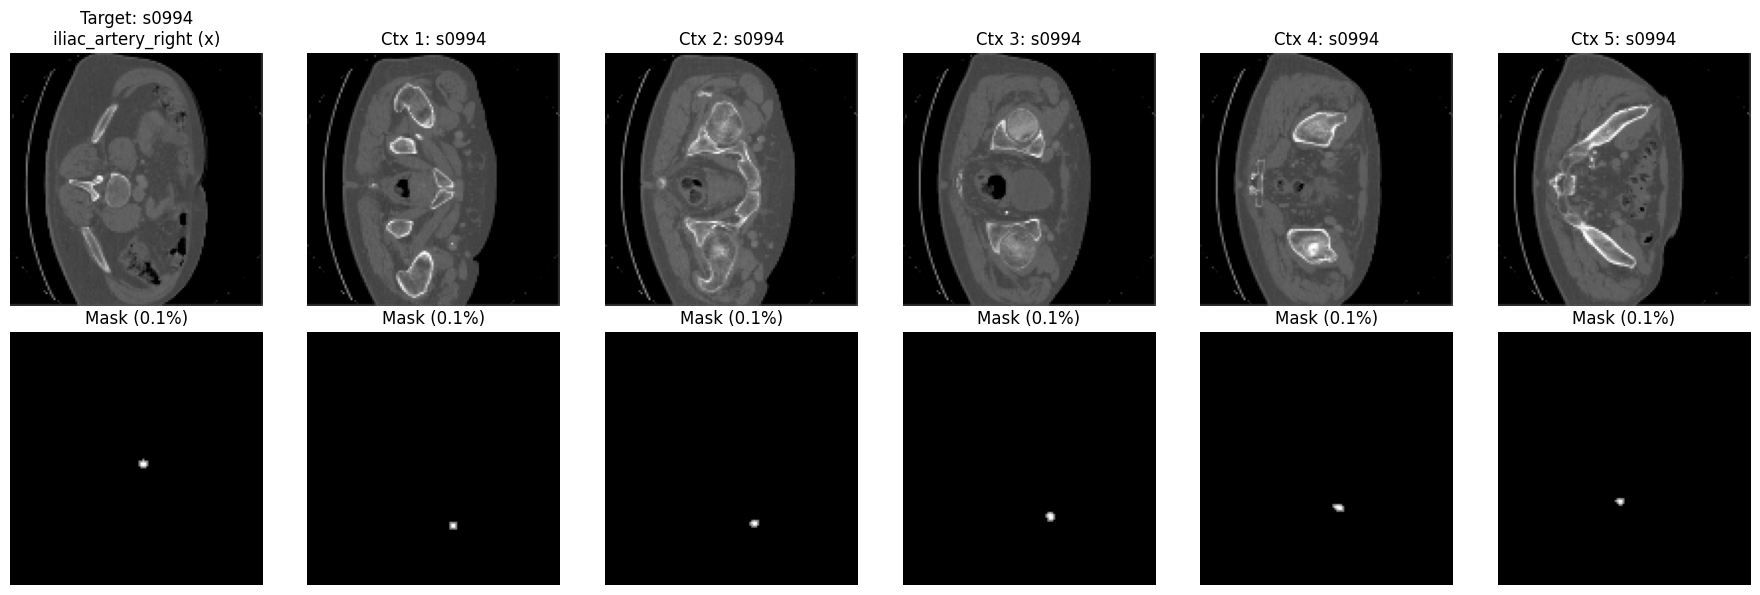

In [4]:
# Visualize a random sample from the dataloader
import random

idx = random.randint(0, len(dataset) - 1)
sample = dataset[idx]

# Extract data
target_img = sample["image"].squeeze().numpy()
target_mask = sample["label"].squeeze().numpy()
context_in = sample.get("context_in")  # [K, 1, H, W]
context_out = sample.get("context_out")  # [K, 1, H, W]

target_case_id = sample["target_case_id"]
label_id = sample["label_id"]
axis = sample["axis"]
context_case_ids = sample.get("context_case_ids", [])

print(f"Sample {idx}: target={target_case_id}, label={label_id}, axis={axis}")
print(f"Target shape: {target_img.shape}, mask coverage: {target_mask.mean()*100:.1f}%")

# Plot
n_ctx = context_in.shape[0] if context_in is not None else 0
n_cols = 1 + n_ctx
fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6))

# Target
axes[0, 0].imshow(target_img, cmap="gray")
axes[0, 0].set_title(f"Target: {target_case_id}\n{label_id} ({axis})")
axes[0, 0].axis("off")
axes[1, 0].imshow(target_mask, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title(f"Mask ({target_mask.mean()*100:.1f}%)")
axes[1, 0].axis("off")

# Context
for i in range(n_ctx):
    ctx_img = context_in[i].squeeze().numpy()
    ctx_mask = context_out[i].squeeze().numpy()
    ctx_case = context_case_ids[i] if i < len(context_case_ids) else "?"
    
    axes[0, i + 1].imshow(ctx_img, cmap="gray")
    axes[0, i + 1].set_title(f"Ctx {i+1}: {ctx_case}")
    axes[0, i + 1].axis("off")
    axes[1, i + 1].imshow(ctx_mask, cmap="gray", vmin=0, vmax=1)
    axes[1, i + 1].set_title(f"Mask ({ctx_mask.mean()*100:.1f}%)")
    axes[1, i + 1].axis("off")

plt.tight_layout()
plt.show()

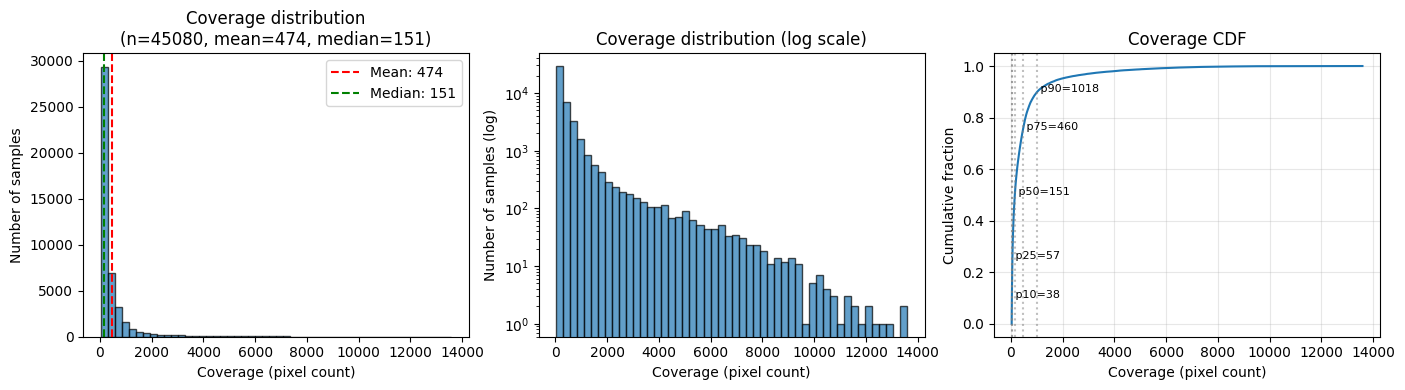

Coverage stats: min=30, max=13588, std=982


In [5]:
# Plot distribution of mask coverage across all dataloader samples
# Use stats coverage values (pixel counts) for efficiency

coverages = []
for case_id, label_id, axis, slice_idx in samples:
    case_stats = stats.get(case_id, {})
    label_stats = case_stats.get("labels", {}).get(label_id, {})
    axis_coverage = label_stats.get("coverage", {}).get(axis, [])
    if slice_idx < len(axis_coverage):
        coverages.append(axis_coverage[slice_idx])

coverages = np.array(coverages)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram of raw coverage (pixel counts)
axes[0].hist(coverages, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Coverage (pixel count)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title(f"Coverage distribution\n(n={len(coverages)}, mean={coverages.mean():.0f}, median={np.median(coverages):.0f})")
axes[0].axvline(coverages.mean(), color='r', linestyle='--', label=f'Mean: {coverages.mean():.0f}')
axes[0].axvline(np.median(coverages), color='g', linestyle='--', label=f'Median: {np.median(coverages):.0f}')
axes[0].legend()

# Log-scale histogram
axes[1].hist(coverages, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Coverage (pixel count)")
axes[1].set_ylabel("Number of samples (log)")
axes[1].set_yscale('log')
axes[1].set_title("Coverage distribution (log scale)")

# CDF
sorted_cov = np.sort(coverages)
cdf = np.arange(1, len(sorted_cov) + 1) / len(sorted_cov)
axes[2].plot(sorted_cov, cdf)
axes[2].set_xlabel("Coverage (pixel count)")
axes[2].set_ylabel("Cumulative fraction")
axes[2].set_title("Coverage CDF")
axes[2].grid(True, alpha=0.3)

# Add percentile markers
for p in [10, 25, 50, 75, 90]:
    val = np.percentile(coverages, p)
    axes[2].axvline(val, color='gray', linestyle=':', alpha=0.5)
    axes[2].text(val, p/100, f' p{p}={val:.0f}', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Coverage stats: min={coverages.min()}, max={coverages.max()}, std={coverages.std():.0f}")